In [1]:
ls

Fair-RAG/                correlation_results/    news/
RQ3_EA.pdf               evaluation.py           plots.ipynb
RQ3_EA.png               evaluation.sh           rag_eval.py
RQ3_EAG.pdf              evaluation_test.py      rag_eval.sh
RQ3_EAG.png              final_evaluation.py     simple_evaluation.ipynb
X/                       final_evaluation.sh     simple_misalignment.py
base_eval.py             final_evaluation_v1.py  spearman.py
base_eval.sh             final_result/           splade.py
bm25.py                  final_trec_2022/        stopword-list.txt
contriver.py             main.ipynb              trec-2021/
correlation_analysis.py  main1.ipynb             trec-2022/
correlation_analysis.sh  main2.ipynb             trec_2021_dataset.ipynb


In [3]:
cd Fair-RAG/utility_labels/eval_results/final_trec_2022/

[Errno 2] No such file or directory: 'Fair-RAG/utility_labels/eval_results/final_trec_2022/'
/mnt/primary/GroupFairnessConsumption/Fair-RAG/utility_labels/eval_results/final_trec_2022


In [4]:
ls

EAG.pdf     EA_RAG.pdf           delta_AQ.png              title_generation/
EAG.png     EA_RAG.png           delta_improvement_AQ.pdf
EA_LLM.pdf  article_generation/  delta_improvement_AQ.png
EA_LLM.png  delta_AQ.pdf         fairness_results.png


In [5]:
tasks = ["title_generation", "article_generation"]
query_topics = {"666": "Cities", "1102": "Geography", "1630": "Military History"}
retrievers = ["bm25", "contriver", "splade"]
llms = ["llama31-8b", "gemma2-9b"]

In [ ]:
# import itertools
# import numpy as np
# import ast

# for task in tasks:
#     for query_topic in query_topics.keys():
#         for retriever in retrievers:
#             for llm in llms:
#                 with open(f"./{task}/{query_topic}/{retriever}/{llm}/5_rouge.txt", "r") as rouge_file:
#                     lines = rouge_file.readlines()
#                     i = 0
#                     fairness_data = {}
#                     while i < len(lines):
#                         line = lines[i].strip()
#                         if line.endswith("_category"):
#                             category_name = line
#                             group_order = list(ast.literal_eval(lines[i + 1].strip()))
#                             scores_dict = ast.literal_eval(lines[i + 2].strip())
                            
#                             values = list(scores_dict.values())
#                             # for x in itertools.combinations(values, 2):
#                             #     print(x)
                            
#                             distance = max(values) - min(values)
                            
#                             fairness_data[category_name] = distance * 100
#                             i += 3
#                         else:
#                             i += 1
#                     print(f"./{task}/{query_topic}/{retriever}/{llm}")
#                     print(fairness_data)

In [121]:
import itertools
import numpy as np
import ast

# Settings
tasks = ["title_generation", "article_generation"]
query_topics = {"666": "Cities", "1102": "Geography", "1630": "Military History"}
retrievers = ["bm25", "contriver", "splade"]
llms = ["llama31-8b", "gemma2-9b"]

# Normalization maps
fairness_map = {
    "creation_date_category": "AoT",
    "years_category": "AoA",
    "relative_pageviews_category": "Pop",
    "first_letter_category": "Alp"
}
# retriever_map = {"bm25": "B", "splade": "S", "contriver": "C"}
llm_map = {"llama31-8b": "L", "gemma2-9b": "G"}
task_map = {"title_generation": "Title Generation",
            "article_generation": "Article Generation"}

# Final data structure
data = {task_map[t]: {col: {fc: {} for fc in fairness_map.values()}
                      for col in query_topics.values()}
        for t in tasks}

# Fill the data structure
for task in tasks:
    for query_topic, col_name in query_topics.items():
        for retriever in retrievers:
            for llm in llms:
                with open(f"./{task}/{query_topic}/{retriever}/{llm}/5_baseline_rouge.txt", "r") as rouge_file: #5_baseline_rouge 5_rouge
                    lines = rouge_file.readlines()
                    i = 0
                    while i < len(lines):
                        line = lines[i].strip()
                        if line.endswith("_category"):
                            category_name = line
                            scores_dict = ast.literal_eval(lines[i + 2].strip())
                            values = list(scores_dict.values())
                            distance = max(values) - min(values)

                            fc = fairness_map[category_name]
                            l = llm_map[llm]

                            data[task_map[task]][col_name][fc][l] = distance * 100
                            i += 3
                        else:
                            i += 1


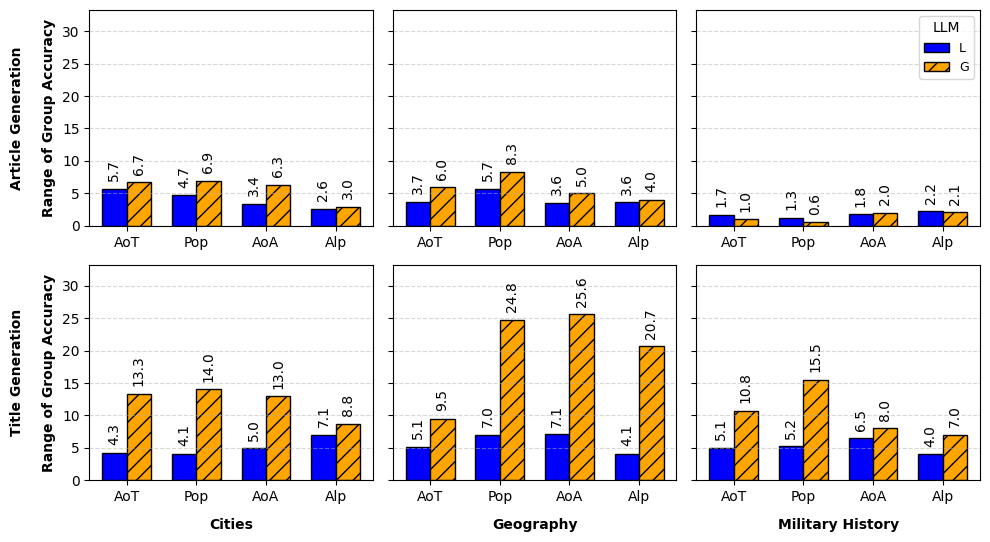

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# Settings
collections = ["Cities", "Geography", "Military History"]
fairness_categories = ["AoT", "Pop", "AoA", "Alp"]
llms = ["L", "G"]  # 'G' will be hatched
tasks = ["Article Generation", "Title Generation"]

# Assign colors per LLM
llm_colors = {"L": "blue", "G": "orange"}

# Compute global max from data
all_values = [
    v
    for task in tasks
    for col in collections
    for fc in fairness_categories
    for l, v in data[task][col][fc].items()
]
global_max = max(all_values)
ymax = global_max * 1.3

fig, axes = plt.subplots(len(tasks), len(collections), figsize=(10, 6), sharey=True)

for row, task in enumerate(tasks):
    for col_idx, col in enumerate(collections):
        ax = axes[row, col_idx] if len(tasks) > 1 else axes[col_idx]
        x = np.arange(len(fairness_categories))
        width = 0.35

        # One bar per LLM
        for llm_idx, llm in enumerate(llms):
            offset = (llm_idx - (len(llms) - 1) / 2) * width
            values = [data[task][col][fc][llm] for fc in fairness_categories]
            hatch_pattern = '//' if llm == 'G' else None

            bars = ax.bar(
                x + offset,
                values,
                width,
                color=llm_colors[llm],
                hatch=hatch_pattern,
                edgecolor='black',
                label=f"{llm}" if row == 0 and col_idx == len(collections) - 1 else ""
            )

            # Add value labels
            for bar, value in zip(bars, values):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + ymax * 0.035,   # small vertical padding
                    f"{value:.1f}",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    rotation=90
                )

        if row == 1:
            ax.set_xlabel(col, fontsize=10, labelpad=10, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(fairness_categories, fontsize=10)
        ax.set_ylim(0, ymax)
        if col_idx == 0:
            ax.set_ylabel(f"{task}\n\nRange of Group Accuracy", fontsize=10, fontweight="bold")
        ax.grid(axis="y", linestyle="--", alpha=0.5)

# Legend
handles, labels = axes[0, -1].get_legend_handles_labels()
axes[0, -1].legend(handles, labels, loc="upper right", title="LLM", fontsize=9) #ncol=len(llms),

plt.tight_layout(rect=[0, 0, 1, 0.92])
# plt.savefig("EA_LLM.png", dpi=1200, bbox_inches="tight")
# plt.savefig("EA_LLM.pdf", bbox_inches="tight")
plt.show()

In [5]:
import itertools
import numpy as np
import ast

# Settings
tasks = ["title_generation", "article_generation"]
query_topics = {"666": "Cities", "1102": "Geography", "1630": "Military History"}
retrievers = ["bm25", "contriver", "splade"]
llms = ["llama31-8b", "gemma2-9b"]

# Normalization maps
fairness_map = {
    "creation_date_category": "AoT",
    "years_category": "AoA",
    "relative_pageviews_category": "Pop",
    "first_letter_category": "Alp"
}
retriever_map = {"bm25": "B", "splade": "S", "contriver": "C"}
llm_map = {"llama31-8b": "L", "gemma2-9b": "G"}
task_map = {"title_generation": "Title Generation",
            "article_generation": "Article Generation"}

# Final data structure
data = {task_map[t]: {col: {fc: {} for fc in fairness_map.values()}
                      for col in query_topics.values()}
        for t in tasks}

# Fill the data structure
for task in tasks:
    for query_topic, col_name in query_topics.items():
        for retriever in retrievers:
            for llm in llms:
                with open(f"./{task}/{query_topic}/{retriever}/{llm}/5_rouge.txt", "r") as rouge_file: #5_baseline_rouge 5_rouge
                    lines = rouge_file.readlines()
                    i = 0
                    while i < len(lines):
                        line = lines[i].strip()
                        if line.endswith("_category"):
                            category_name = line
                            scores_dict = ast.literal_eval(lines[i + 2].strip())
                            values = list(scores_dict.values())
                            distance = max(values) - min(values)

                            fc = fairness_map[category_name]
                            r = retriever_map[retriever]
                            l = llm_map[llm]

                            data[task_map[task]][col_name][fc][(r, l)] = distance * 100
                            i += 3
                        else:
                            i += 1

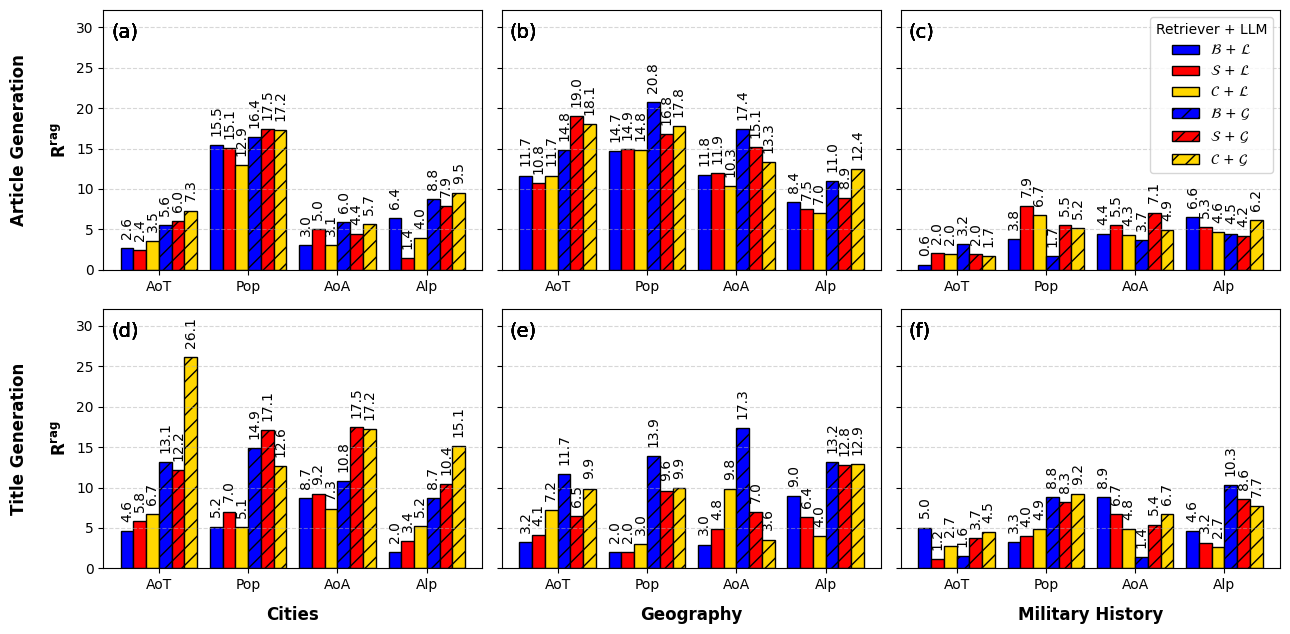

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Settings
collections = ["Cities", "Geography", "Military History"]
fairness_categories = ["AoT", "Pop", "AoA", "Alp"]
retrievers = ["B", "S", "C"]
llms = ["L", "G"]  # 'G' will be hatched
tasks = ["Article Generation", "Title Generation"]

# Assign red, blue, yellow per retriever
retriever_colors = {
    "B": "blue",    # Blue
    "S": "red",     # Red
    "C": "gold",    # Yellow
}

# Compute global max from data
all_values = [
    v
    for task in tasks
    for col in collections
    for fc in fairness_categories
    for (r, l), v in data[task][col][fc].items()
]
global_max = max(all_values)
ymax = global_max * 1.23

fig, axes = plt.subplots(len(tasks), len(collections), figsize=(13, 7), sharey=True)

bar_width = 0.5          # wider bars
group_spacing = 0.5        # extra space between fairness groups

subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']


for row, task in enumerate(tasks):
    for col_idx, col in enumerate(collections):
        ax = axes[row, col_idx] if len(tasks) > 1 else axes[col_idx]

        # positions of groups (add spacing)
        x = np.arange(len(fairness_categories)) * (len(retrievers)*len(llms) * bar_width + group_spacing)

        # Draw bars for each (retriever, llm)
        for llm_idx, llm in enumerate(llms):
            for r_idx, retriever in enumerate(retrievers):
                combo_idx = llm_idx * len(retrievers) + r_idx
                offset = (combo_idx - (len(retrievers)*len(llms) - 1) / 2) * bar_width

                values = [data[task][col][fc][(retriever, llm)] for fc in fairness_categories]
                hatch_pattern = '//' if llm == 'G' else None

                bars = ax.bar(
                    x + offset,
                    values,
                    bar_width,
                    color=retriever_colors[retriever],
                    hatch=hatch_pattern,
                    edgecolor="black",
                    label=rf"$\mathcal{{{retriever}}}$ + $\mathcal{{{llm}}}$" if row == 0 and col_idx == len(collections) - 1 else ""
                    # label=f"{retriever}+{llm}" if row == 0 and col_idx == len(collections) - 1 else ""
                )

                # Add value labels vertically
                for bar, value in zip(bars, values):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + ymax * 0.035,
                        f"{value:.1f}",
                        ha="center",
                        va="bottom",
                        fontsize=10,
                        rotation=90
                    )

                ax.text(
                    0.02, 0.95,
                    subplot_labels[row * len(collections) + col_idx],
                    transform=ax.transAxes,
                    fontsize=14,
                    # fontweight='bold',
                    va='top',
                    ha='left'
                )

        if row == 1:
            ax.set_xlabel(f"{col}", fontsize=12, labelpad=10, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(fairness_categories, fontsize=10) #fontweight="bold"
        ax.set_ylim(0, ymax)
        # for label in ax.get_yticklabels():
        #     label.set_fontweight("bold")
        if col_idx == 0:
            ax.set_ylabel(f"{task}\n\n$\mathbf{{R^{{rag}}}}$", fontsize=12, fontweight="bold") #
        ax.grid(axis="y", linestyle="--", alpha=0.5)

# Legend
# handles, labels = axes[0, -1].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper center", ncol=len(retrievers)*len(llms),
#            title="Retriever + LLM", fontsize=8)

# Get handles and labels
handles, labels = axes[0, -1].get_legend_handles_labels()

# Add the legend inside the top-right subplot
axes[0, -1].legend(
    handles,
    labels,
    loc="upper right",        # position inside the axes
    fontsize=10,
    title="Retriever + LLM",
    title_fontsize=10, 
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("EA_RAG.png", dpi=1200, bbox_inches="tight")
plt.savefig("EA_RAG.pdf", bbox_inches="tight")
plt.show()


In [ ]:
import itertools
import numpy as np
import ast

for task in tasks:
    for query_topic in query_topics.keys():
        for retriever in retrievers:
            for llm in llms:
                with open(f"./{task}/{query_topic}/{retriever}/{llm}/5_rouge.txt", "r") as rouge_file:
                    lines = rouge_file.readlines()
                    i = 0
                    fairness_data = {}
                    while i < len(lines):
                        line = lines[i].strip()
                        if line.endswith("_category"):
                            category_name = line
                            group_order = list(ast.literal_eval(lines[i + 1].strip()))
                            scores_dict = ast.literal_eval(lines[i + 2].strip())
                            fairness_data[category_name] = scores_dict
                            i += 3
                        else:
                            i += 1
                
                with open(f"./{task}/{query_topic}/{retriever}/{llm}/5_baseline_rouge.txt", "r") as rouge_file:
                    lines = rouge_file.readlines()
                    i = 0
                    baseline_fairness_data = {}
                    while i < len(lines):
                        line = lines[i].strip()
                        if line.endswith("_category"):
                            category_name = line
                            group_order = list(ast.literal_eval(lines[i + 1].strip()))
                            scores_dict = ast.literal_eval(lines[i + 2].strip())
                            baseline_fairness_data[category_name] = scores_dict
                            i += 3
                        else:
                            i += 1
                
                for (cat1, fair_val), (cat2, base_val) in zip(fairness_data.items(), baseline_fairness_data.items()):
                    if cat1 != cat2:
                        print(f"Warning: category mismatch: {cat1} vs {cat2}")
                    differences = {k: fair_val[k] - base_val[k] for k in fair_val}
                    # Get all pairwise absolute differences
                    vals = list(differences.values())
                    if len(list(itertools.combinations(vals, 2))) != 6:
                        print("*************************************here")
                    pairwise_diffs = [abs(a - b) for a, b in itertools.combinations(vals, 2)]
                
                    avg_distance = np.mean(pairwise_diffs)

                    differenc = max(list(differences.values())) - min(list(differences.values()))
                    print("Differences:", differenc * 100)
                    print("Average distance:", avg_distance * 100)

In [29]:
import itertools
import numpy as np
import ast

# Settings
tasks = ["title_generation", "article_generation"]
query_topics = {"666": "Cities", "1102": "Geography", "1630": "Military History"}
retrievers = ["bm25", "contriver", "splade"]
llms = ["llama31-8b", "gemma2-9b"]

# Normalization maps
fairness_map = {
    "creation_date_category": "AoT",
    "years_category": "AoA",
    "relative_pageviews_category": "Pop",
    "first_letter_category": "Alp"
}
retriever_map = {"bm25": "B", "splade": "S", "contriver": "C"}
llm_map = {"llama31-8b": "L", "gemma2-9b": "G"}
task_map = {"title_generation": "Title Generation",
            "article_generation": "Article Generation"}

# Final data structure
data = {task_map[t]: {col: {fc: {} for fc in fairness_map.values()}
                      for col in query_topics.values()}
        for t in tasks}

# Fill the data structure
for task in tasks:
    for query_topic, col_name in query_topics.items():
        for retriever in retrievers:
            for llm in llms:
                
                fairness_data = {}
                with open(f"./{task}/{query_topic}/{retriever}/{llm}/5_rouge.txt", "r") as rouge_file:
                    lines = rouge_file.readlines()
                    i = 0
                    while i < len(lines):
                        line = lines[i].strip()
                        if line.endswith("_category"):
                            category_name = line
                            group_order = list(ast.literal_eval(lines[i + 1].strip()))
                            scores_dict = ast.literal_eval(lines[i + 2].strip())
                            fairness_data[category_name] = scores_dict
                            i += 3
                        else:
                            i += 1
                            
                baseline_fairness_data = {}
                with open(f"./{task}/{query_topic}/{retriever}/{llm}/5_baseline_rouge.txt", "r") as rouge_file:
                    lines = rouge_file.readlines()
                    i = 0
                    while i < len(lines):
                        line = lines[i].strip()
                        if line.endswith("_category"):
                            category_name = line
                            group_order = list(ast.literal_eval(lines[i + 1].strip()))
                            scores_dict = ast.literal_eval(lines[i + 2].strip())
                            baseline_fairness_data[category_name] = scores_dict
                            i += 3
                        else:
                            i += 1

                r = retriever_map[retriever]
                l = llm_map[llm]
                
                for (cat1, fair_val), (cat2, base_val) in zip(fairness_data.items(), baseline_fairness_data.items()):
                    if cat1 != cat2:
                        print(f"Warning: category mismatch: {cat1} vs {cat2}")

                    differences = {k: fair_val[k] - base_val[k] for k in fair_val}

                    # vals = list(differences.values())
                    # pairwise_diffs = [abs(a - b) for a, b in itertools.combinations(vals, 2)]
                    # avg_distance = np.mean(pairwise_diffs)

                    distance = (max(list(differences.values())) - min(list(differences.values()))) * 100
                    fc = fairness_map[cat1]
                    data[task_map[task]][col_name][fc][(r, l)] = distance

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Settings
# collections = ["Cities", "Geography", "Military History"]
# fairness_categories = ["AoT", "Pop", "AoA", "Alp"]
# retrievers = ["B", "S", "C"]
# llms = ["L", "G"]
# tasks = ["Article Generation", "Title Generation"]

# # Compute global max value from data
# all_values = [
#     v
#     for task in tasks
#     for col in collections
#     for fc in fairness_categories
#     for (r, l), v in data[task][col][fc].items()
# ]
# global_max = max(all_values)
# ymax = global_max * 1.1  # add 10% headroom

# # Plot grouped bar charts: one row per task
# fig, axes = plt.subplots(len(tasks), len(collections), figsize=(10, 6), sharey=True)

# for row, task in enumerate(tasks):
#     for col_idx, col in enumerate(collections):
#         ax = axes[row, col_idx] if len(tasks) > 1 else axes[col_idx]
#         x = np.arange(len(fairness_categories))  # positions for fairness categories
#         width = 0.12  # bar width
#         offsets = np.linspace(-width*len(retrievers)*len(llms)/2,
#                               width*len(retrievers)*len(llms)/2,
#                               len(retrievers)*len(llms))
        
#         # Plot bars for each retriever+LLM combo
#         for i, (r, l) in enumerate([(r, l) for r in retrievers for l in llms]):
#             aq_values = [data[task][col][fc][(r, l)] for fc in fairness_categories]
#             ax.bar(x + offsets[i], aq_values, width, label=f"{r}+{l}")
        
#         # Titles only on top row
#         # if row == 1:
#         #     ax.set_title(f"{col}", fontsize=10)
#         if row == 1:  # only for second row
#             ax.set_xlabel(f"{col}", fontsize=10, labelpad=4)  # labelpad controls distance

#         ax.set_xticks(x)
#         ax.set_xticklabels(fairness_categories, fontsize=8)
#         ax.set_ylim(0, ymax)  # <-- dynamic limit
#         if col_idx == 0:
#             ax.set_ylabel(f"{task}\n\nRange of AQ Metric (ΔAQ)", fontsize=9)
#         ax.grid(axis="y", linestyle="--", alpha=0.6)

# # One legend for the entire figure
# handles, labels = axes[0, -1].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper center", ncol=6, title="Retriever + LLM", fontsize=8)

# plt.tight_layout(rect=[0, 0, 1, 0.92])

# # Save high resolution
# plt.savefig("delta_improvement_AQ.png", dpi=600, bbox_inches="tight")
# plt.savefig("delta_improvement_AQ.pdf", bbox_inches="tight")
# plt.show()

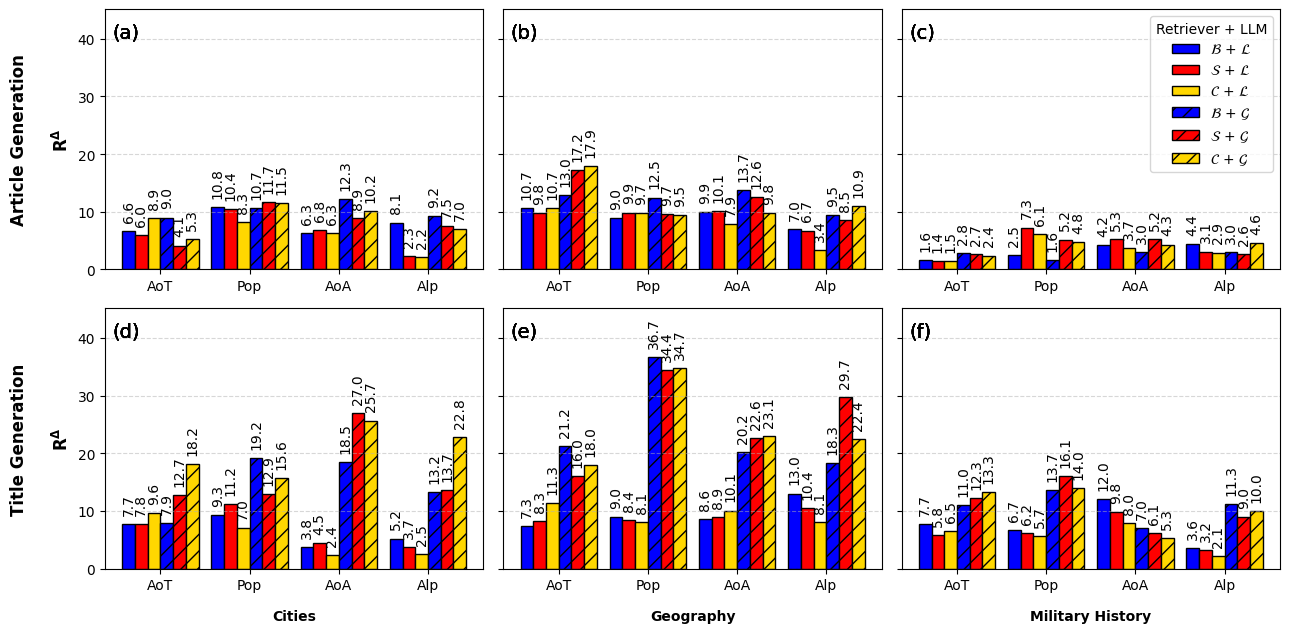

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Settings
collections = ["Cities", "Geography", "Military History"]
fairness_categories = ["AoT", "Pop", "AoA", "Alp"]
retrievers = ["B", "S", "C"]
llms = ["L", "G"]  # 'G' will be hatched
tasks = ["Article Generation", "Title Generation"]

# Assign red, blue, yellow per retriever
retriever_colors = {
    "B": "blue",    # Blue
    "S": "red",     # Red
    "C": "gold",    # Yellow
}

# Compute global max from data
all_values = [
    v
    for task in tasks
    for col in collections
    for fc in fairness_categories
    for (r, l), v in data[task][col][fc].items()
]
global_max = max(all_values)
ymax = global_max * 1.23

fig, axes = plt.subplots(len(tasks), len(collections), figsize=(13, 7), sharey=True)

bar_width = 0.5          # wider bars
group_spacing = 0.5        # extra space between fairness groups

subplot_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']


for row, task in enumerate(tasks):
    for col_idx, col in enumerate(collections):
        ax = axes[row, col_idx] if len(tasks) > 1 else axes[col_idx]

        # positions of groups (add spacing)
        x = np.arange(len(fairness_categories)) * (len(retrievers)*len(llms) * bar_width + group_spacing)

        # Draw bars for each (retriever, llm)
        for llm_idx, llm in enumerate(llms):
            for r_idx, retriever in enumerate(retrievers):
                combo_idx = llm_idx * len(retrievers) + r_idx
                offset = (combo_idx - (len(retrievers)*len(llms) - 1) / 2) * bar_width

                values = [data[task][col][fc][(retriever, llm)] for fc in fairness_categories]
                hatch_pattern = '//' if llm == 'G' else None

                bars = ax.bar(
                    x + offset,
                    values,
                    bar_width,
                    color=retriever_colors[retriever],
                    hatch=hatch_pattern,
                    edgecolor="black",
                    label=rf"$\mathcal{{{retriever}}}$ + $\mathcal{{{llm}}}$" if row == 0 and col_idx == len(collections) - 1 else ""
                    # label=f"{retriever}+{llm}" if row == 0 and col_idx == len(collections) - 1 else ""
                )

                # Add value labels vertically
                for bar, value in zip(bars, values):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + ymax * 0.035,
                        f"{value:.1f}",
                        ha="center",
                        va="bottom",
                        fontsize=10,
                        rotation=90
                    )

                ax.text(
                    0.02, 0.95,
                    subplot_labels[row * len(collections) + col_idx],
                    transform=ax.transAxes,
                    fontsize=14,
                    # fontweight='bold',
                    va='top',
                    ha='left'
                )

        if row == 1:
            ax.set_xlabel(f"{col}", fontsize=10, labelpad=12, fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(fairness_categories, fontsize=10) #fontweight="bold"
        ax.set_ylim(0, ymax)
        # for label in ax.get_yticklabels():
        #     label.set_fontweight("bold")
        if col_idx == 0:
            ax.set_ylabel(f"{task}\n\n$\mathbf{{R^{{\Delta}}}}$", fontsize=12, fontweight="bold") #
        ax.grid(axis="y", linestyle="--", alpha=0.5)




# for row, task in enumerate(tasks):
#     for col_idx, col in enumerate(collections):
#         ax = axes[row, col_idx] if len(tasks) > 1 else axes[col_idx]
#         x = np.arange(len(fairness_categories))
#         width = 0.13

#         # Group bars by LLM, retriever inside each LLM group
#         for llm_idx, llm in enumerate(llms):
#             for r_idx, retriever in enumerate(retrievers):
#                 combo_idx = llm_idx * len(retrievers) + r_idx
#                 offset = (combo_idx - (len(retrievers)*len(llms) - 1) / 2) * width

#                 values = [data[task][col][fc][(retriever, llm)] for fc in fairness_categories]
#                 hatch_pattern = '//' if llm == 'G' else None

#                 bars = ax.bar(
#                     x + offset,
#                     values,
#                     width,
#                     color=retriever_colors[retriever],
#                     hatch=hatch_pattern,
#                     edgecolor='black',  # to make hatching clearer
#                     label=f"{retriever}+{llm}" if row == 0 and col_idx == len(collections) - 1 else ""
#                 )
#                 # Add value labels vertically
#                 for bar, value in zip(bars, values):
#                     ax.text(
#                         bar.get_x() + bar.get_width() / 2,
#                         bar.get_height() + ymax * 0.035,
#                         f"{value:.1f}",
#                         ha="center",
#                         va="bottom",
#                         fontsize=10,
#                         rotation=90
#                     )

#         if row == 1:
#             ax.set_xlabel(f"{col}", fontsize=10, labelpad=10, fontweight="bold")

#         ax.set_xticks(x)
#         ax.set_xticklabels(fairness_categories, fontsize=10)
#         ax.set_ylim(0, ymax)
#         if col_idx == 0:
#             ax.set_ylabel(f"{task}\n\n Range of $\mathbf{{\Delta}}$[AC(g)]", fontsize=10, fontweight="bold")
#         ax.grid(axis="y", linestyle="--", alpha=0.5)

# Legend
handles, labels = axes[0, -1].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper center", ncol=len(retrievers)*len(llms),
#            title="Retriever + LLM", fontsize=8)

axes[0, -1].legend(
    handles,
    labels,
    loc="upper right",        # position inside the axes
    fontsize=10,
    title="Retriever + LLM",
    title_fontsize=10, 
    frameon=True
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("EAG.png", dpi=1200, bbox_inches="tight")
plt.savefig("EAG.pdf", bbox_inches="tight")
plt.show()

In [1]:
import os
import re
import numpy as np
import pandas as pd

# Mapping from query topic ID → collection name
collection_map = {
    "666": "Cities",
    "1102": "Geography",
    "1630": "Military History",
}

# Mapping category names → short names for plotting
fairness_map = {
    "creation_date_category": "AoT",
    "years_category": "AoA",
    "relative_pageviews_category": "Pop",
    "first_letter_category": "Alp"
}

# Map long bar names → short names for plotting
bar_map = {
    "utility vs consumption": "U-vs-A",
    "utility vs exposure": "U-vs-E",
    "exposure vs consumption": "E-vs-A",
}
bars = list(bar_map.values())  # ["U-vs-A", "U-vs-E", "E-vs-A"]

# Map LLM names → short codes for plotting
llm_map = {
    "gemma2-9b": "G",
    "llama31-8b": "L",
}

# Map task names → nice labels for plotting
task_map = {
    "title_generation": "Title Generation",
    "article_generation": "Article Generation",
}


def parse_file(filepath):
    with open(filepath, "r") as f:
        text = f.read()

    # Extract metadata
    query_topic = re.search(r"Query topic: \['(\d+)'\]", text).group(1)
    llm_raw = re.search(r"LLM: \['(.+?)'\]", text).group(1)
    task_raw = re.search(r"Task: (.+)", text).group(1).strip()
    collection = collection_map[query_topic]

    # Apply mappings to keep consistency with plotting code
    llm = llm_map.get(llm_raw, llm_raw)  
    task = task_map.get(task_raw, task_raw)

    # Split into category blocks
    blocks = re.split(r"\*{10,}", text)
    data = {}

    for block in blocks[1:]:  # skip header
        lines = [l.strip() for l in block.strip().split("\n") if l.strip()]
        if not lines:
            continue
        category = lines[0]
        metrics = {}
        for i in range(1, len(lines), 3):  # every 3 lines = one pair
            pair = lines[i]
            spearman_line = lines[i+1]
            spearman_val = float(spearman_line.split(":")[-1].strip())
            if pair in bar_map:
                metrics[bar_map[pair]] = spearman_val

        data[category] = metrics

    return llm, task, collection, data


def load_all_txt(directory):
    records = []
    for fname in os.listdir(directory):
        if fname.endswith(".txt"):
            print(fname)
            llm, task, collection, data = parse_file(os.path.join(directory, fname))
            for cat, short_cat in fairness_map.items():
                for raw_bar, short_bar in bar_map.items():
                    val = data[cat].get(short_bar)
                    records.append((llm, task, collection, short_cat, short_bar, val))

    df = pd.DataFrame(records, columns=["LLM", "Task", "Collection", "Category", "Bar", "Spearman"])
    return df


# Example usage
directory = "./correlation_results/"
df = load_all_txt(directory)

# Pivot into numpy array for plotting
llms = ["L", "G"]  # fixed order
tasks = ["Article Generation", "Title Generation"]  # fixed order
collections = ["Cities", "Geography", "Military History"]
fairness_categories = ["AoT", "AoA", "Alp", "Pop"]

n_llms = len(llms)
n_tasks = len(tasks)
n_collections = len(collections)
n_categories = len(fairness_categories)
n_bars = len(bars)

data_all = np.full((n_llms, n_tasks, n_collections, n_categories, n_bars), np.nan)

for i, llm in enumerate(llms):
    for j, task in enumerate(tasks):
        for k, col in enumerate(collections):
            for f, cat in enumerate(fairness_categories):
                for b, bar in enumerate(bars):
                    val = df.loc[
                        (df["LLM"] == llm) &
                        (df["Task"] == task) &
                        (df["Collection"] == col) &
                        (df["Category"] == cat) &
                        (df["Bar"] == bar),
                        "Spearman"
                    ]
                    if not val.empty:
                        data_all[i, j, k, f, b] = val.values[0]

print("Shape of data_all:", data_all.shape)


tg_l318b_666.txt
ag_g29b_1102.txt
ag_l318b_1630.txt
tg_g29b_1102.txt
ag_g29b_1630.txt
ag_g29b_666.txt
tg_l318b_1630.txt
tg_l318b_1102.txt
ag_l318b_666.txt
ag_l318b_1102.txt
tg_g29b_666.txt
tg_g29b_1630.txt
Shape of data_all: (2, 2, 3, 4, 3)


In [ ]:
data_all

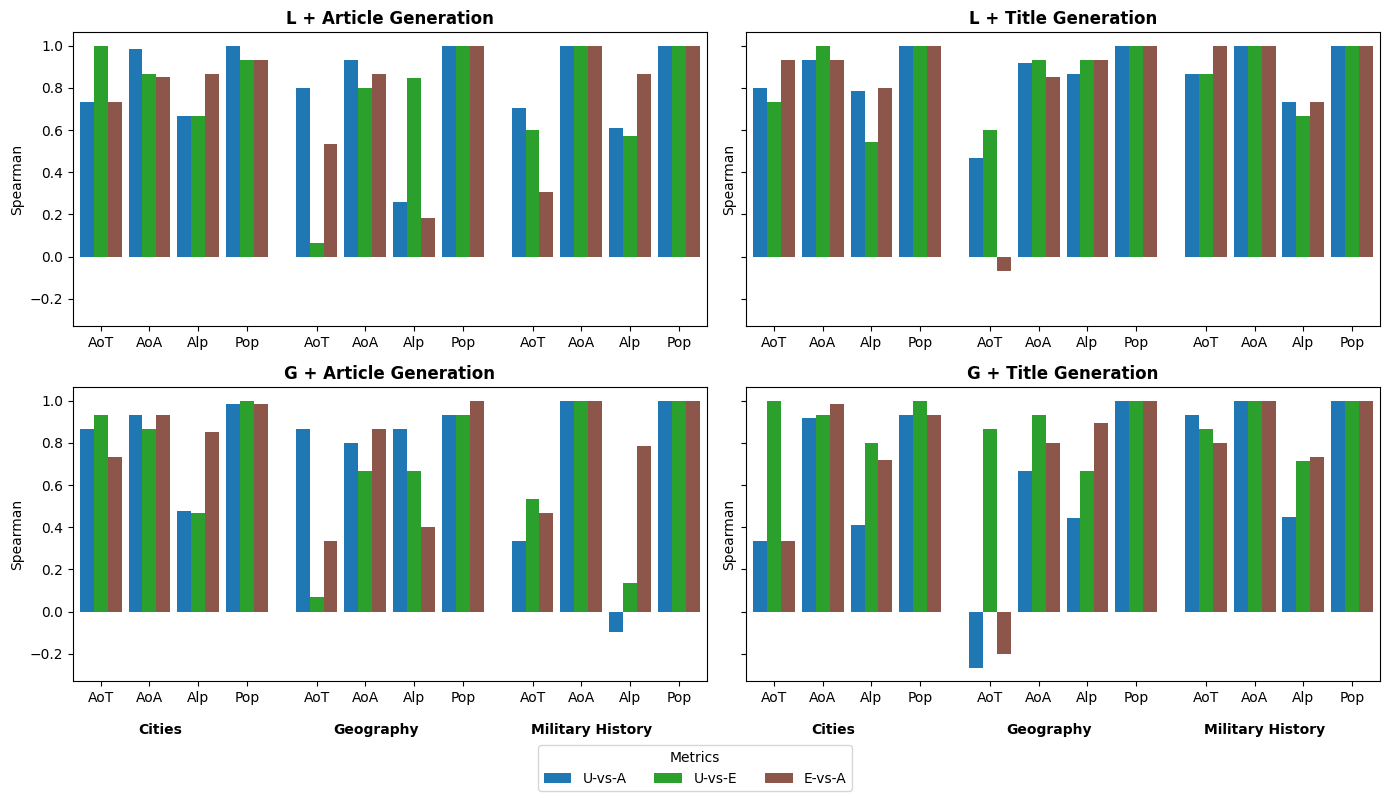

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Pivot into numpy array for plotting
llms = ["L", "G"]  # fixed order
tasks = ["Article Generation", "Title Generation"]  # fixed order
collections = ["Cities", "Geography", "Military History"]
fairness_categories = ["AoT", "AoA", "Alp", "Pop"]
n_collections = len(collections)
n_categories = len(fairness_categories)
n_bars = 3
bars = ["U-vs-A", "U-vs-E", "E-vs-A"]

bar_width = 0.1
inner_spacing = 0.05
group_width = n_bars * bar_width + inner_spacing
cat_group_width = n_categories * group_width
collection_spacing = 0.15

# colors = ["steelblue", "orange", "green"]
colors = [
    "#1f77b4",  # Blue   (B+L)
    "#2ca02c",  # Green  (S+L)
    "#8c564b",  # Brown  (C+G)
]

def plot_one(ax, data, title, show_collections=False):
    handles = []
    labels = []
    for c in range(n_collections):
        for f in range(n_categories):
            for b in range(n_bars):
                x_pos = c * (cat_group_width + collection_spacing) + f * group_width + b * bar_width
                bar = ax.bar(x_pos, data[c, f, b], width=bar_width, color=colors[b],
                             label=bars[b] if c == 0 and f == 0 else "")
                if c == 0 and f == 0:
                    handles.append(bar[0])
                    labels.append(bars[b])

    # xticks
    xticks, xtick_labels = [], []
    for c, col in enumerate(collections):
        base = c * (cat_group_width + collection_spacing)
        for f, cat in enumerate(fairness_categories):
            center = base + f * group_width + (group_width - inner_spacing)/2 - 0.05
            xticks.append(center)
            xtick_labels.append(cat)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)

    # collection labels (only once, e.g. bottom row)
    if show_collections:
        for c, col in enumerate(collections):
            start = c * (cat_group_width + collection_spacing)
            end = start + n_categories * group_width
            center = (start + end - group_width) / 2
            ax.annotate(col, xy=(center, 0), xycoords='data',
                        xytext=(0, -80), textcoords='offset points',
                        ha='center', va='top', fontsize=10, fontweight='bold')

    ax.set_ylabel("Spearman")
    # Compute global min and max from all data
    ymin = np.nanmin(data_all)
    ymax = np.nanmax(data_all)
    
    margin = 0.05 * (ymax - ymin)  # 5% margin
    ymin -= margin
    ymax += margin

    ax.set_ylim(ymin, ymax)

    first_bar = 0
    last_bar = (n_collections - 1) * (cat_group_width + collection_spacing) + n_categories * group_width
    ax.set_xlim(first_bar - 0.1, last_bar - 0.05)

    ax.set_title(title, fontsize=12, fontweight="bold")

    return handles, labels

# ---- Plot 2×2 grid ----
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

handles, labels = None, None
for i in range(2):       # LLMs
    for j in range(2):   # Tasks
        show_collections = (i == 1)  # only bottom row shows collection labels
        h, l = plot_one(axes[i, j], data_all[i, j], f"{llms[i]} + {tasks[j]}", show_collections)
        if handles is None:  # grab legend only from first subplot
            handles, labels = h, l

# Shared legend at bottom
fig.legend(handles, labels, title="Metrics", loc="lower center", ncol=3, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("fairness_2x2.png", dpi=600, bbox_inches="tight")
plt.savefig("fairness_2x2.pdf", bbox_inches="tight")
plt.show()

In [40]:
import os
import re
import numpy as np
import pandas as pd

# Mapping from query topic ID → collection name
collection_map = {
    "666": "Cities",
    "1102": "Geography",
    "1630": "Military History",
}

# Mapping category names → short names for plotting
fairness_map = {
    "creation_date_category": "AoT",
    "years_category": "AoA",
    "relative_pageviews_category": "Pop",
    "first_letter_category": "Alp"
}

# Map long bar names → short names for plotting
bar_map = {
    "utility vs performence": "U-vs-AQ",
    "exposure vs performence": "E-vs-AQ",
    "consumption vs performence": "A-vs-AQ",
    # "c-to-u vs performence": "AUR-vs-AQ",
    # "c-to-e vs performence": "AER-vs-AQ"
}
bars = list(bar_map.values())  # ["U-vs-A", "U-vs-E", "E-vs-A"]

# Map LLM names → short codes for plotting
llm_map = {
    "gemma2-9b": "G",
    "llama31-8b": "L",
}

# Map task names → nice labels for plotting
task_map = {
    "title_generation": "Title Generation",
    "article_generation": "Article Generation",
}


def parse_file(filepath):
    with open(filepath, "r") as f:
        text = f.read()

    # Extract metadata
    query_topic = re.search(r"Query topic: \['(\d+)'\]", text).group(1)
    llm_raw = re.search(r"LLM: \['(.+?)'\]", text).group(1)
    task_raw = re.search(r"Task: (.+)", text).group(1).strip()
    collection = collection_map[query_topic]

    # Apply mappings to keep consistency with plotting code
    llm = llm_map.get(llm_raw, llm_raw)  
    task = task_map.get(task_raw, task_raw)

    # Split into category blocks
    blocks = re.split(r"\*{10,}", text)
    data = {}

    for counter, block in enumerate(blocks[1:]):  # skip header
        lines = [l.strip() for l in block.strip().split("\n") if l.strip()]
        if not lines:
            continue
        category = lines[0]
        metrics = {}
        for i in range(1, len(lines), 4):  # every 3 lines = one pair
            pair = lines[i]
            spearman_line = lines[i+3]
            if pair == "utility vs consumption":
                break
            spearman_val = float(spearman_line.split(":")[-1].strip())
            if pair in bar_map:
                metrics[bar_map[pair]] = spearman_val

        data[category] = metrics

    return llm, task, collection, data


def load_all_txt(directory):
    records = []
    for fname in os.listdir(directory):
        if fname.endswith(".txt"):
            print(fname)
            llm, task, collection, data = parse_file(os.path.join(directory, fname))
            for cat, short_cat in fairness_map.items():
                for raw_bar, short_bar in bar_map.items():
                    val = data[cat].get(short_bar)
                    records.append((llm, task, collection, short_cat, short_bar, val))

    df = pd.DataFrame(records, columns=["LLM", "Task", "Collection", "Category", "Bar", "Spearman"])
    return df


# Example usage
directory = "./correlation_results/"
df = load_all_txt(directory)

# Pivot into numpy array for plotting
llms = ["L", "G"]  # fixed order
tasks = ["Article Generation", "Title Generation"]  # fixed order
collections = ["Cities", "Geography", "Military History"]
fairness_categories = ["AoT", "AoA", "Alp", "Pop"]

n_llms = len(llms)
n_tasks = len(tasks)
n_collections = len(collections)
n_categories = len(fairness_categories)
n_bars = len(bars)

data_all = np.full((n_llms, n_tasks, n_collections, n_categories, n_bars), np.nan)

for i, llm in enumerate(llms):
    for j, task in enumerate(tasks):
        for k, col in enumerate(collections):
            for f, cat in enumerate(fairness_categories):
                for b, bar in enumerate(bars):
                    val = df.loc[
                        (df["LLM"] == llm) &
                        (df["Task"] == task) &
                        (df["Collection"] == col) &
                        (df["Category"] == cat) &
                        (df["Bar"] == bar),
                        "Spearman"
                    ]
                    if not val.empty:
                        data_all[i, j, k, f, b] = val.values[0]

print("Shape of data_all:", data_all.shape)


tg_l318b_666.txt
ag_g29b_1102.txt
ag_l318b_1630.txt
tg_g29b_1102.txt
ag_g29b_1630.txt
ag_g29b_666.txt
tg_l318b_1630.txt
tg_l318b_1102.txt
ag_l318b_666.txt
ag_l318b_1102.txt
tg_g29b_666.txt
tg_g29b_1630.txt
Shape of data_all: (2, 2, 3, 4, 3)


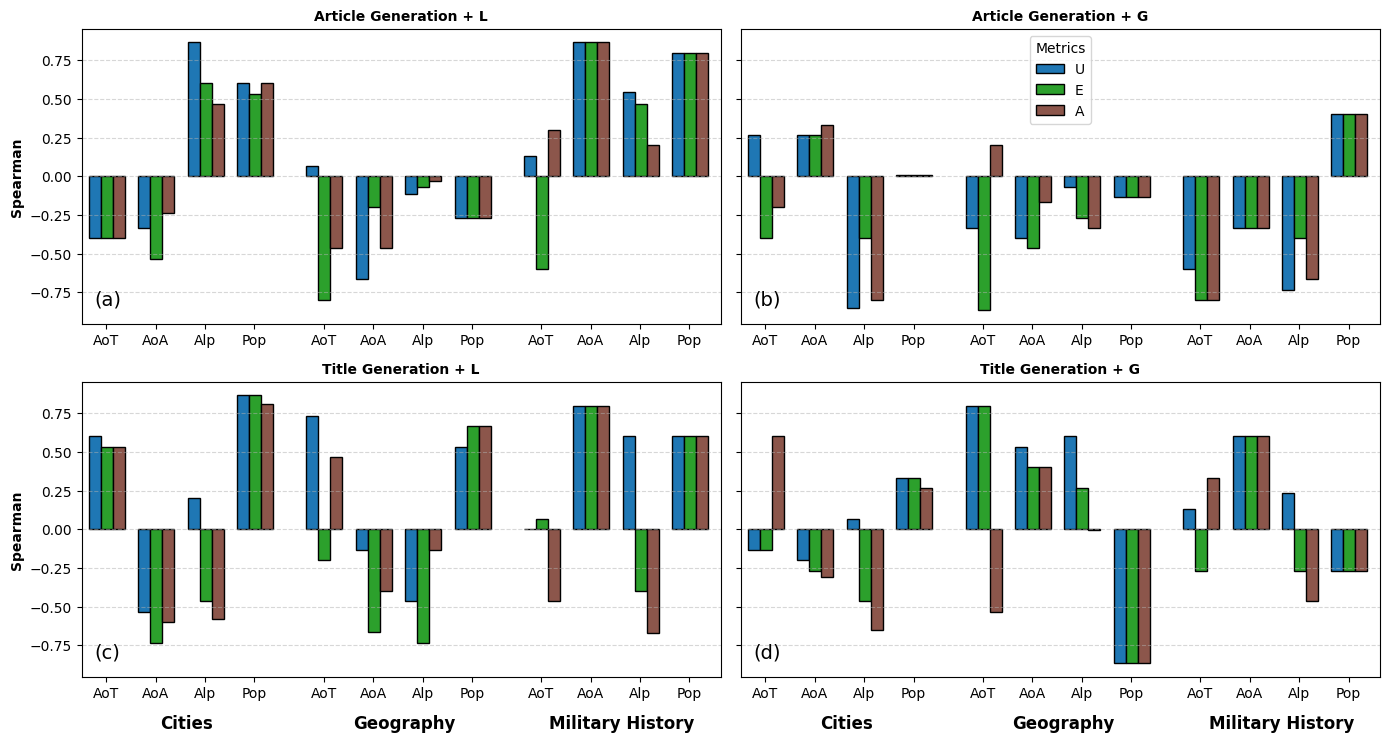

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Pivot into numpy array for plotting
llms = ["L", "G"]  # fixed order
tasks = ["Article Generation", "Title Generation"]  # fixed order
collections = ["Cities", "Geography", "Military History"]
fairness_categories = ["AoT", "AoA", "Alp", "Pop"]
n_collections = len(collections)
n_categories = len(fairness_categories)
# n_bars = 5
# bars = ["U-vs-AQ", "E-vs-AQ", "A-vs-AQ", "AUR-vs-AQ", "AER-vs-AQ"]

n_bars = 3
bars = ["U", "E", "A"]

bar_width = 0.09
inner_spacing = 0.1
group_width = n_bars * bar_width + inner_spacing
cat_group_width = n_categories * group_width - inner_spacing
collection_spacing = 0.25

# colors = ["steelblue", "orange", "green"]

# colors = [
#     "#1f77b4",  # Blue   (B+L)
#     "#ff7f0e",  # Orange (B+G)
#     "#2ca02c",  # Green  (S+L)
#     "#d62728",  # Red    (S+G)
#     "#9467bd",  # Purple (C+L)
#     "#8c564b",  # Brown  (C+G)
# ]
colors = [
    "#1f77b4",  # Blue   
    "#2ca02c",  # Green  
    "#8c564b",  # Brown  
    # "#FFD700",  # Yellow
    # "#d62728"  # Red
]

epsilon = 0.009999999999
def plot_one(ax, data, title, show_collections, show_ylabel, alphabet):
    handles = []
    labels = []
    for c in range(n_collections):
        for f in range(n_categories):
            for b in range(n_bars):
                value = data[c, f, b]
                if data[c, f, b] == 0:
                    # print("***************************")
                    value = data[c, f, b] + epsilon
                x_pos = c * (cat_group_width + collection_spacing) + f * group_width + b * bar_width
                bar = ax.bar(x_pos, value, width=bar_width, color=colors[b], edgecolor="black",
                             label=bars[b] if c == 0 and f == 0 else "")
                if c == 0 and f == 0:
                    handles.append(bar[0])
                    labels.append(bars[b])

    # xticks
    xticks, xtick_labels = [], []
    for c, col in enumerate(collections):
        base = c * (cat_group_width + collection_spacing)
        for f, cat in enumerate(fairness_categories):
            center = base + f * group_width + (group_width - inner_spacing)/2 - 0.05
            xticks.append(center)
            xtick_labels.append(cat)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)

    ax.text(
            0.02, 0.05,
            alphabet,
            transform=ax.transAxes,
            fontsize=14,
            # fontweight='bold',
            va='bottom',
            ha='left'
        )
    
    # collection labels (only once, e.g. bottom row)
    if show_collections:
        for c, col in enumerate(collections):
            start = c * (cat_group_width + collection_spacing)
            end = ((c+1) * cat_group_width) + (c * collection_spacing)#n_categories * group_width
            center = (start + end) / 2
            ax.annotate(col, xy=(center, 0), xycoords='data',
                        xytext=(0, -133), textcoords='offset points',
                        ha='center', va='top', fontsize=12, fontweight='bold')
    if show_ylabel:
        ax.set_ylabel("Spearman", fontsize=10, fontweight='bold')
    # Compute global min and max from all data
    ymin = np.nanmin(data_all)
    ymax = np.nanmax(data_all)
    
    margin = 0.05 * (ymax - ymin)  # 5% margin
    ymin -= margin
    ymax += margin

    ax.set_ylim(ymin, ymax)

    first_bar = 0
    last_bar = (n_collections - 1) * (cat_group_width + collection_spacing) + n_categories * group_width
    ax.set_xlim(first_bar - 0.1, last_bar - 0.05)

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    return handles, labels

# ---- Plot 2×2 grid ----
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)

subplot_labels = ['(a)', '(b)', '(c)', '(d)']
handles, labels = None, None
for i in range(2):       # LLMs
    for j in range(2):   # Tasks
        show_collections = (i == 1)  # only bottom row shows collection labels
        show_ylabel = (j == 0)
        h, l = plot_one(axes[i, j], data_all[i, j], f"{tasks[i]} + {llms[j]}", show_collections, show_ylabel, subplot_labels[i*2 + j])
        if handles is None:  # grab legend only from first subplot
            handles, labels = h, l

# Shared legend at bottom
# fig.legend(handles, labels, title="Metrics", loc="lower center", ncol=5, fontsize=10)

# Legend
handles, labels = axes[0, -1].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper center", ncol=len(retrievers)*len(llms),
#            title="Retriever + LLM", fontsize=8)

axes[0, -1].legend(
    handles,
    labels,
    loc="upper center",        # position inside the axes
    fontsize=10,
    title="Metrics",
    title_fontsize=10, 
    frameon=True)


plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.savefig("RQ3_EAG.png", dpi=1200, bbox_inches="tight")
plt.savefig("RQ3_EAG.pdf", bbox_inches="tight")
plt.show()

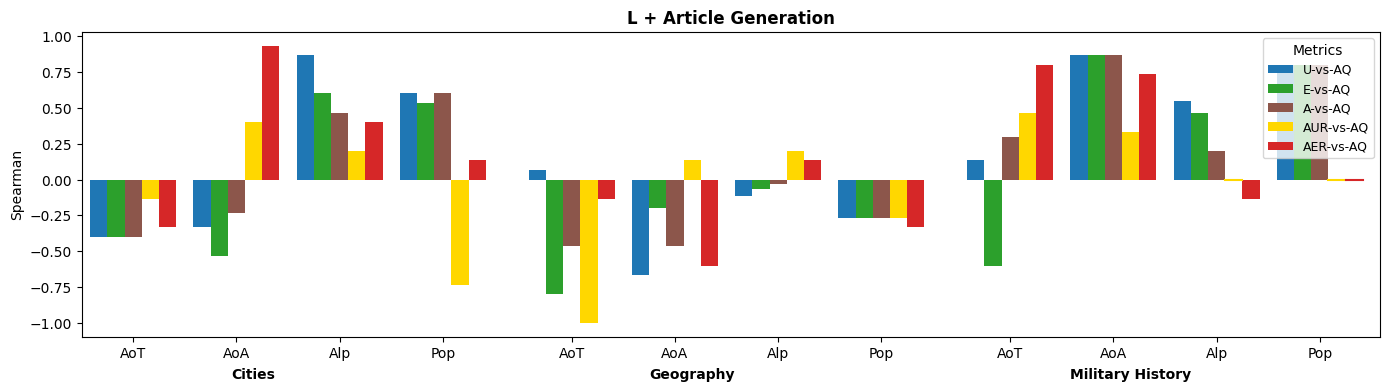

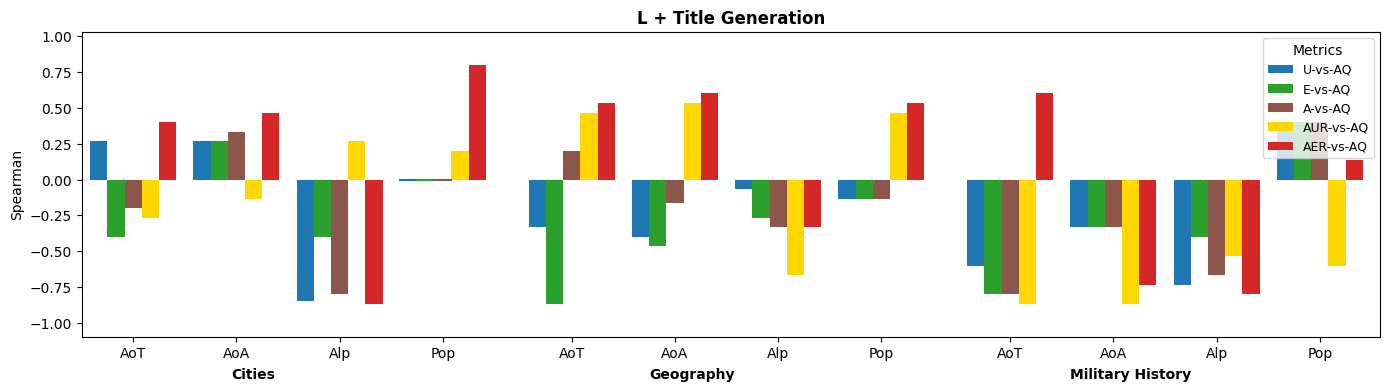

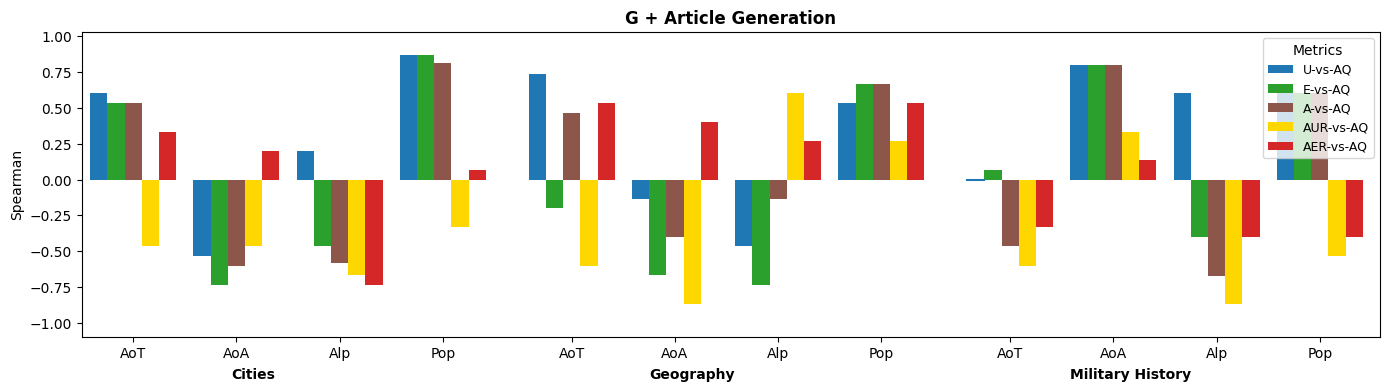

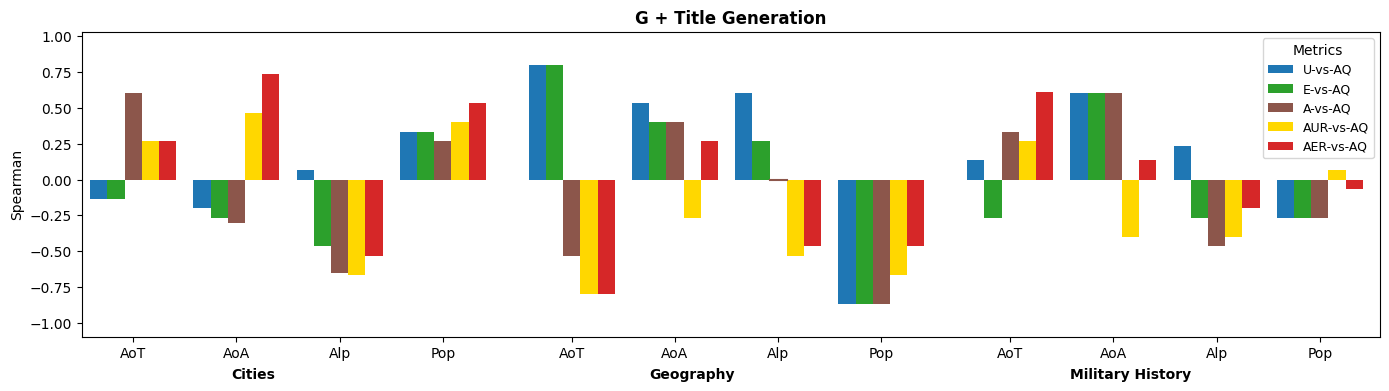

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Setup ----
llms = ["L", "G"]
tasks = ["Article Generation", "Title Generation"]
collections = ["Cities", "Geography", "Military History"]
fairness_categories = ["AoT", "AoA", "Alp", "Pop"]
n_collections = len(collections)
n_categories = len(fairness_categories)
n_bars = 5
bars = ["U-vs-AQ", "E-vs-AQ", "A-vs-AQ", "AUR-vs-AQ", "AER-vs-AQ"]

bar_width = 0.1
inner_spacing = 0.1
group_width = n_bars * bar_width + inner_spacing
cat_group_width = n_categories * group_width
collection_spacing = 0.15

colors = [
    "#1f77b4",  # Blue   
    "#2ca02c",  # Green  
    "#8c564b",  # Brown  
    "#FFD700",  # Yellow
    "#d62728"   # Red
]

# ---- Plot Function ----
def plot_one(data, title, filename):
    fig, ax = plt.subplots(figsize=(14, 4))
    handles = []
    labels = []
    for c in range(n_collections):
        for f in range(n_categories):
            for b in range(n_bars):
                x_pos = c * (cat_group_width + collection_spacing) + f * group_width + b * bar_width
                bar = ax.bar(x_pos, data[c, f, b], width=bar_width, color=colors[b],
                             label=bars[b] if c == 0 and f == 0 else "")
                val = data[c, f, b]
                if (val <= 0.005) and (val >= -0.005):
                    # Draw a thin horizontal line to indicate zero
                    ax.plot([x_pos - bar_width/2, x_pos + bar_width/2], [0, 0],
                            color=colors[b], linewidth=1.5)
                else:
                    bar = ax.bar(x_pos, val, width=bar_width, color=colors[b],
                                 label=bars[b] if c == 0 and f == 0 else "")
                    if c == 0 and f == 0:
                        handles.append(bar[0])
                        labels.append(bars[b])

    # xticks
    xticks, xtick_labels = [], []
    for c, col in enumerate(collections):
        base = c * (cat_group_width + collection_spacing)
        for f, cat in enumerate(fairness_categories):
            center = base + f * group_width + (group_width - inner_spacing)/2 - 0.05
            xticks.append(center)
            xtick_labels.append(cat)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)

    # Collection labels
    for c, col in enumerate(collections):
        start = c * (cat_group_width + collection_spacing)
        end = start + n_categories * group_width
        center = (start + end - group_width) / 2
        ax.annotate(col, xy=(center, 0), xycoords='data',
                    xytext=(0, -135), textcoords='offset points',
                    ha='center', va='top', fontsize=10, fontweight='bold')

    # Axis limits
    ymin = np.nanmin(data_all)
    ymax = np.nanmax(data_all)
    margin = 0.05 * (ymax - ymin)
    ax.set_ylim(ymin - margin, ymax + margin)
    first_bar = 0
    last_bar = (n_collections - 1) * (cat_group_width + collection_spacing) + n_categories * group_width
    ax.set_xlim(first_bar - 0.1, last_bar - 0.05)

    ax.set_ylabel("Spearman")
    ax.set_title(title, fontsize=12, fontweight="bold")

    # Legend
    ax.legend(handles, labels, title="Metrics", loc="upper right", fontsize=9)

    # Save & show
    plt.tight_layout()
    plt.savefig(f"{filename}.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{filename}.pdf", bbox_inches="tight")
    plt.show()

# ---- Generate Four Individual Plots ----
for i in range(2):  # LLMs
    for j in range(2):  # Tasks
        llm = llms[i]
        task = tasks[j]
        title = f"{llm} + {task}"
        filename = f"fairness_vs_performance_{llm}_{task.replace(' ', '_')}"
        plot_one(data_all[i, j], title, filename)


In [9]:
import pandas as pd
import os
from collections import defaultdict

# Canonical subgroup ordering for each fairness category
FAIRNESS_ORDERINGS = {
    "creation_date": ["2001-2006", "2007-2011", "2012-2016", "2017-2022"],
    "first_letter": ["a-d", "e-k", "l-r", "s-"],
    "relative_pageviews": ["Low", "Medium-Low", "Medium-High", "High"],
    "years": ["Unknown", "Pre-1900s", "20th century", "21st century"]
}
# Mapping from filenames to table shorthand labels
CATEGORY_MAP = {
    "creation_date": "AoT",
    "years": "AoA",
    "relative_pageviews": "Pop",
    "first_letter": "Alp"
}

def load_fairness_results(file_path, wikiproject, llm, retriever, table_task, fairness_category):
    df = pd.read_csv(file_path)
    ordering = FAIRNESS_ORDERINGS[fairness_category]
    subgroup_col = df.columns[0]  # first unnamed column
    # print(subgroup_col)
    # print(df)
    df = df.set_index(subgroup_col).reindex(ordering).reset_index()
    # print(df)
    # print(df.columns)
    # print(df)
    aur_values = df["C-to-U Ratio"].tolist()
    aur_values = [round(x, 2) for x in aur_values]

    aer_values = df["C-to-E Ratio"].tolist()
    aer_values = [round(x, 2) for x in aer_values]

    return {
        (wikiproject, llm, retriever, CATEGORY_MAP[fairness_category], table_task): {
            "aur": tuple(aur_values),
            "aer": tuple(aer_values),
        }
    }

# def build_latex_table(all_results, template_file="table_template.tex", output_file="table_filled.tex"):
#     with open(template_file, "r") as f:
#         latex = f.read()
#     for collection_id, collection_name in collections.items():
#         for llm, llm_short in llms.items():
#             for retriever, retriever_short in retrievers.items():
#                 for fairness_category in CATEGORY_MAP.values():
#                     for task, table_task in tasks.items():
#                         metrics = all_results[(collection_name, llm_short, retriever_short, fairness_category, table_task)]
#                         aur_str = f"({', '.join(f'{x:.3f}' for x in metrics['aur'])})"
#                         aer_str = f"({', '.join(f'{x:.3f}' for x in metrics['aer'])})"

#                         # how to fill the table
                        
                
#                         latex = latex.replace(placeholder, replacement)

#     with open(output_file, "w") as f:
#         f.write(latex)


llms = {"llama31-8b": "L", "gemma2-9b": "G"}
collections = {"666": "Cities", "1102": "Geography", "1630": "Military History"}
retrievers = {"bm25": "B", "contriver": "C", "splade": "S"}
tasks = {"article_generation": "Article Generation", "title_generation": "Title Generation"}
# Example usage
if __name__ == "__main__":
    all_results = {}    
    for llm, llm_short in llms.items():
        for collection_id, collection_name in collections.items():
            for retriever, retriever_short in retrievers.items():
                for task, table_task in tasks.items():
                    for fairness_category in CATEGORY_MAP.keys():
                        res = load_fairness_results(
                            os.path.join(
                                "final_result",
                                "final_trec_2022",
                                task,
                                collection_id,
                                retriever,
                                llm,
                                "roberta-large-mnli",
                                f"{fairness_category}_category_aggregated_result.csv"),
                            wikiproject=collection_name,
                            llm=llm_short,
                            retriever=retriever_short,
                            table_task=table_task,
                            fairness_category=fairness_category
                        )
                        all_results.update(res)
                        # print(all_results)
                        
    # Now fill LaTeX table
    # build_latex_table(all_results, "table_template.tex", "table_filled.tex")
    # print("Table filled and written to table_filled.tex ✅")

In [34]:
print("\multirow{24}{*}{Military History}") 
print("& \multirow{12}{*}{G}")
print("& \multirow{4}{*}{B}")

C = "Military History"
LLM = "G"
Retriever = "B"
Fairness_category = "AoT" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"& AoT &{x1}&{x2}&{x3}&{x4}\\\\")


Fairness_category = "AoA" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"&   &   & AoA &{x1}&{x2}&{x3}&{x4}\\\\")


Fairness_category = "Pop" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"&   &   & Pop &{x1}&{x2}&{x3}&{x4}\\\\")


Fairness_category = "Alp" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"&   &   & Alp &{x1}&{x2}&{x3}&{x4}\\\\")
print("\cline{4-8}")





print("& & \multirow{4}{*}{C}")
Retriever = "C"
Fairness_category = "AoT" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"& AoT &{x1}&{x2}&{x3}&{x4}\\\\")


Fairness_category = "AoA" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"&   &   & AoA &{x1}&{x2}&{x3}&{x4}\\\\")


Fairness_category = "Pop" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"&   &   & Pop &{x1}&{x2}&{x3}&{x4}\\\\")


Fairness_category = "Alp" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"&   &   & Alp &{x1}&{x2}&{x3}&{x4}\\\\")
print("\cline{4-8}")




print("& & \multirow{4}{*}{S}")
Retriever = "S"
Fairness_category = "AoT" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"& AoT &{x1}&{x2}&{x3}&{x4}\\\\")


Fairness_category = "AoA" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"&   &   & AoA &{x1}&{x2}&{x3}&{x4}\\\\")


Fairness_category = "Pop" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"&   &   & Pop &{x1}&{x2}&{x3}&{x4}\\\\")


Fairness_category = "Alp" # "AoT" "AoA" "Pop" "Alp"
tuple = (C, LLM, Retriever, Fairness_category, "Article Generation")
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]) + "&", end='')
x1 = all_results[tuple]["aur"]
x2 = all_results[tuple]["aer"]
tuple = (C, LLM, Retriever, Fairness_category, "Title Generation")
x3 = all_results[tuple]["aur"]
x4 = all_results[tuple]["aer"]
# print(str(all_results[tuple]["aur"]) + "&" + str(all_results[tuple]["aer"]))
print(f"&   &   & Alp &{x1}&{x2}&{x3}&{x4}\\\\")
print("\cline{4-8}")

\multirow{24}{*}{Military History}
& \multirow{12}{*}{L}
& \multirow{4}{*}{B}
& AoT &(0.81, 0.93, 1.1, 1.17)&(0.76, 0.84, 1.15, 1.36)&(1.14, 0.99, 1.0, 0.87)&(1.0, 0.93, 1.11, 1.01)\\
&   &   & AoA &(1.24, 0.68, 0.66, 0.53)&(1.18, 0.51, 0.82, 0.72)&(1.38, 0.68, 0.8, 0.7)&(1.24, 0.7, 0.86, 0.84)\\
&   &   & Pop &(1.04, 0.95, 0.96, 0.77)&(0.95, 1.15, 1.07, 1.05)&(1.03, 0.96, 0.91, 1.14)&(1.08, 0.94, 0.87, 0.83)\\
&   &   & Alp &(0.95, 0.86, 1.39, 0.79)&(1.12, 0.82, 1.18, 0.8)&(1.12, 0.89, 1.01, 0.96)&(1.04, 0.97, 0.96, 1.01)\\
\cline{4-8}
& & \multirow{4}{*}{C}
& AoT &(0.98, 0.9, 1.0, 1.19)&(0.87, 0.86, 1.13, 1.29)&(1.1, 1.01, 0.95, 0.93)&(0.92, 1.03, 1.05, 1.02)\\
&   &   & AoA &(1.09, 1.05, 0.85, 0.78)&(1.13, 0.73, 0.93, 1.09)&(1.16, 0.93, 0.82, 1.11)&(1.07, 0.92, 0.87, 1.28)\\
&   &   & Pop &(0.99, 0.99, 0.78, 1.87)&(0.94, 1.02, 0.91, 2.58)&(1.04, 1.0, 0.84, 0.98)&(1.09, 1.0, 0.79, 0.74)\\
&   &   & Alp &(1.28, 0.63, 1.22, 0.86)&(1.29, 0.68, 1.17, 0.81)&(1.11, 1.07, 0.93, 0.88)&(1.06,

In [ ]:
\multirow{24}{*}{Geography} 
  & \multirow{12}{*}{L} 
    & \multirow{4}{*}{B} 
      & AoT &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\
    &   &   & AoA &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\
    &   &   & Pop &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\
    &   &   & Alp &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\ \cline{4-8}
  &   & \multirow{4}{*}{C} 
      & AoT &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\
    &   &   & AoA &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\
    &   &   & Pop &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\
    &   &   & Alp &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\ \cline{4-8}
  &   & \multirow{4}{*}{S} 
      & AoT &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\
    &   &   & AoA &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\
    &   &   & Pop &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\
    &   &   & Alp &(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)&(..., ..., ..., ...)\\ \cline{4-8}

In [2]:
ls

Fair-RAG/                correlation_results/    news/
RQ3_EA.pdf               evaluation.py           plots.ipynb
RQ3_EA.png               evaluation.sh           rag_eval.py
RQ3_EAG.pdf              evaluation_test.py      rag_eval.sh
RQ3_EAG.png              final_evaluation.py     simple_evaluation.ipynb
X/                       final_evaluation.sh     simple_misalignment.py
base_eval.py             final_evaluation_v1.py  spearman.py
base_eval.sh             final_result/           splade.py
bm25.py                  final_trec_2022/        stopword-list.txt
contriver.py             main.ipynb              trec-2021/
correlation_analysis.py  main1.ipynb             trec-2022/
correlation_analysis.sh  main2.ipynb             trec_2021_dataset.ipynb


In [3]:
cd final_trec_2022/

/mnt/primary/GroupFairnessConsumption/final_trec_2022


In [4]:
import pandas as pd

In [5]:
corpus = pd.read_csv("corpus.csv")

In [6]:
corpus.columns

Index(['docno', 'title', 'text'], dtype='object')